In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")
df.head()

,order_date,category,city,sales,profit
0,2025-01-01,Food,Karachi,4954,836
1,2025-01-02,Electronics,Karachi,342,908
2,2025-01-03,Food,Islamabad,2690,363
3,2025-01-04,Food,Karachi,1163,983
4,2025-01-05,Electronics,Lahore,4424,159


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   order_date  500 non-null    str  
 1   category    500 non-null    str  
 2   city        500 non-null    str  
 3   sales       500 non-null    int64
 4   profit      500 non-null    int64
dtypes: int64(2), str(3)
memory usage: 19.7 KB


,sales,profit
count,500.000000,500.000000
mean,2632.886000,512.874000
std,1425.998235,293.427909
min,103.000000,21.000000
25%,1403.250000,261.750000
50%,2733.500000,517.000000
75%,3804.000000,760.250000
max,4995.000000,997.000000


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [5]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day
df['day_of_week'] = df['order_date'].dt.day_name()
df['quarter'] = df['order_date'].dt.quarter

In [6]:
holidays = pd.to_datetime([
    '2025-01-01',
    '2025-08-14',
    '2025-12-25'
])

df['is_holiday'] = df['order_date'].isin(holidays).astype(int)

In [7]:
category_encoded = pd.get_dummies(df['category'], prefix='category', dtype=int)
df = pd.concat([df, category_encoded], axis=1)

In [8]:
city_encoded = pd.get_dummies(df['city'], prefix='city', dtype=int)
df = pd.concat([df, city_encoded], axis=1)

In [9]:
df.head()

,order_date,category,city,sales,profit,year,month,day,day_of_week,quarter,is_holiday,category_Clothing,category_Electronics,category_Food,city_Islamabad,city_Karachi,city_Lahore
0,2025-01-01,Food,Karachi,4954,836,2025,1,1,Wednesday,1,1,0,0,1,0,1,0
1,2025-01-02,Electronics,Karachi,342,908,2025,1,2,Thursday,1,0,0,1,0,0,1,0
2,2025-01-03,Food,Islamabad,2690,363,2025,1,3,Friday,1,0,0,0,1,1,0,0
3,2025-01-04,Food,Karachi,1163,983,2025,1,4,Saturday,1,0,0,0,1,0,1,0
4,2025-01-05,Electronics,Lahore,4424,159,2025,1,5,Sunday,1,0,0,1,0,0,0,1


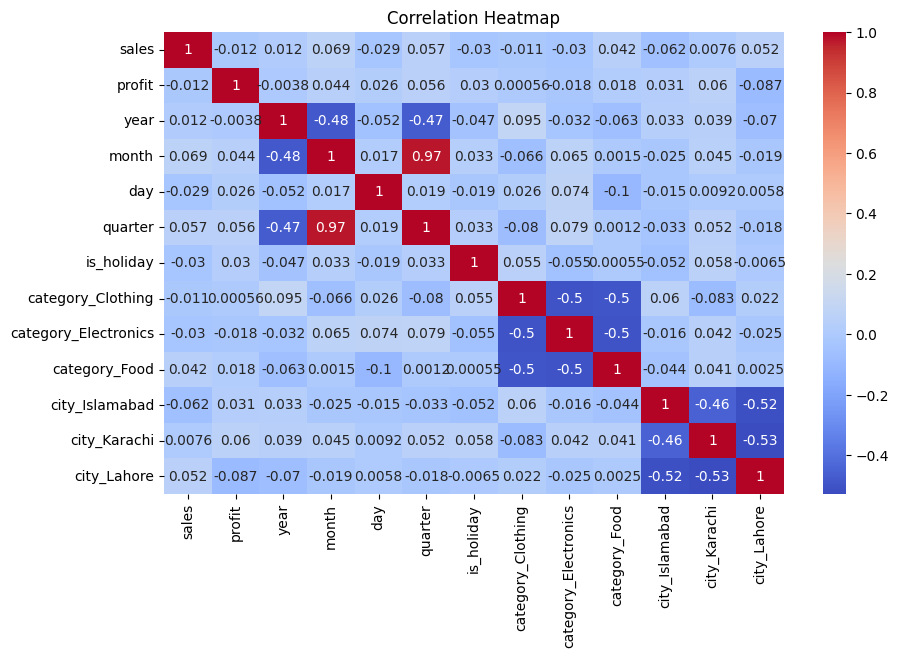

In [10]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

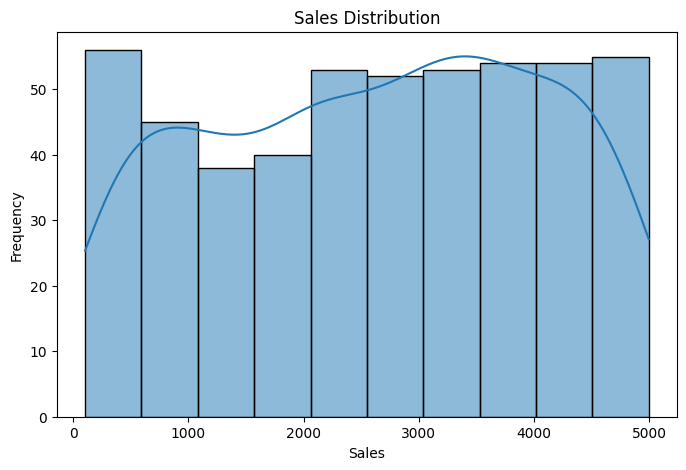

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['sales'], kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

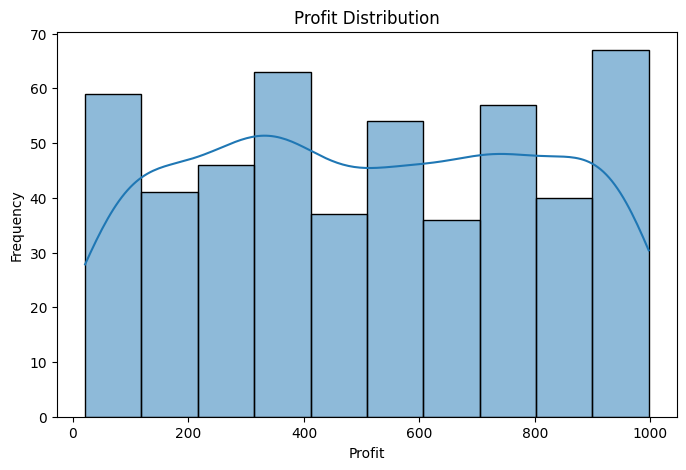

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['profit'], kde=True)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

In [13]:
df.to_csv("features_v1.csv", index=False)

print("features_v1.csv exported successfully!")

features_v1.csv exported successfully!
